In [7]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.datasets import get_rdataset

In [2]:
df = get_rdataset("AirPassengers").data
df.columns = ["time", "passengers"]

print(df.shape)
print(df.describe())

(144, 2)
              time  passengers
count   144.000000  144.000000
mean   1954.958333  280.298611
std       3.476109  119.966317
min    1949.000000  104.000000
25%    1951.979167  180.000000
50%    1954.958333  265.500000
75%    1957.937500  360.500000
max    1960.916667  622.000000


In [6]:
df


,time,passengers
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
...,...,...
139,1960.583333,606
140,1960.666667,508
141,1960.750000,461
142,1960.833333,390


In [ ]:

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df["passengers"])
ax.set_title("Monthly airline passengers 1949–1960")
ax.set_xlabel("Month index")
ax.set_ylabel("Passengers (thousands)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.show()
# fig.savefig("airline_raw.png", dpi=150)

# EDA

/var/folders/w1/1vybnxrx6t16f0__7k0t0_8m0000gn/T/ipykernel_45837/3877937352.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


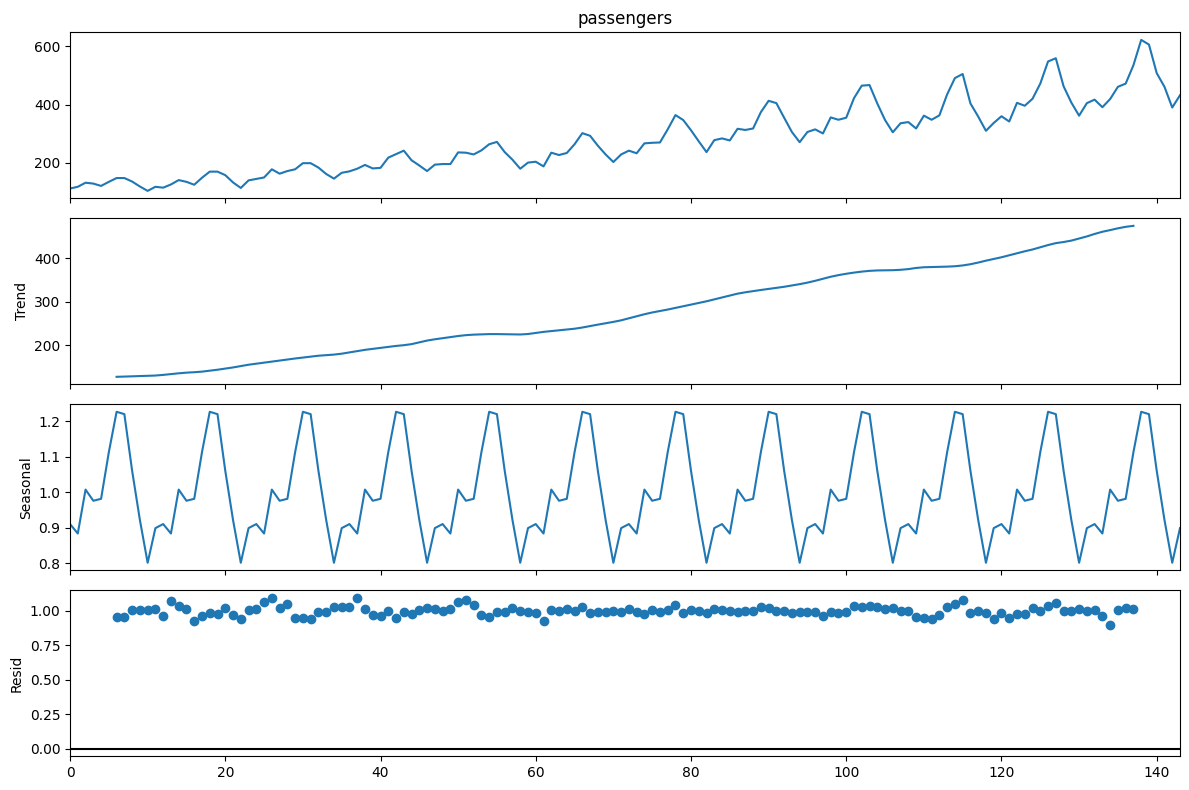

In [18]:
df = get_rdataset("AirPassengers").data
df.columns = ["time", "passengers"]

series = df["passengers"]

decomposition = seasonal_decompose(series, model="multiplicative", period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.tight_layout()
fig.show()
# fig.savefig("airline_decompose.png", dpi=150)

# model building

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.93350D+00    |proj g|=  1.11436D+00

At iterate    1    f=  4.74425D+00    |proj g|=  1.06685D+01

At iterate    2    f=  4.28493D+00    |proj g|=  1.33721D+00

At iterate    3    f=  3.97345D+00    |proj g|=  3.01577D+00

At iterate    4    f=  3.91519D+00    |proj g|=  2.39796D+00

At iterate    5    f=  3.85158D+00    |proj g|=  3.66609D+00

At iterate    6    f=  3.79534D+00    |proj g|=  1.78171D+00

At iterate    7    f=  3.73908D+00    |proj g|=  5.58263D-01

At iterate    8    f=  3.71524D+00    |proj g|=  6.20678D-01

At iterate    9    f=  3.70629D+00    |proj g|=  8.64009D-01

At iterate   10    f=  3.68404D+00    |proj g|=  1.49922D+00

At iterate   11    f=  3.66856D+00    |proj g|=  8.36938D-01

At iterate   12    f=  3.65812D+00    |proj g|=  3.15876D-01

At iterate   13    f=  3.6

/var/folders/w1/1vybnxrx6t16f0__7k0t0_8m0000gn/T/ipykernel_45837/1790419978.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


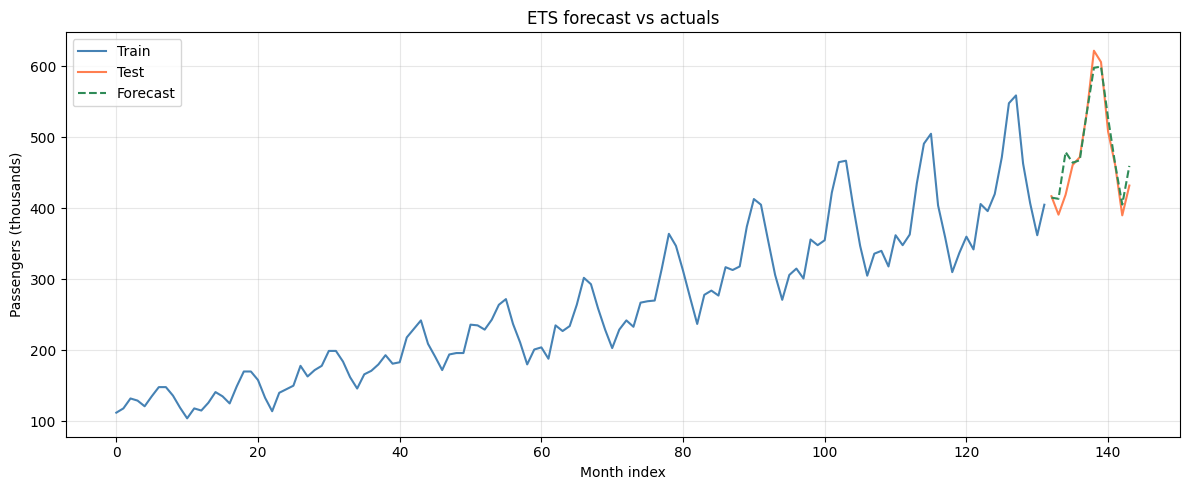

In [19]:
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

df = get_rdataset("AirPassengers").data
df.columns = ["time", "passengers"]

series = df["passengers"]

train = series.iloc[:132]
test = series.iloc[132:]

model = ETSModel(train, error="mul", trend="mul", seasonal="mul", seasonal_periods=12)
fit = model.fit()

print(fit.summary())

forecast = fit.forecast(12)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.values, label="Train", color="steelblue")
ax.plot(range(len(train), len(train) + len(test)), test.values, label="Test", color="coral")
ax.plot(range(len(train), len(train) + len(forecast)), forecast.values, label="Forecast", color="seagreen", linestyle="--")
ax.set_title("ETS forecast vs actuals")
ax.set_xlabel("Month index")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.show()
# fig.savefig("airline_ets_forecast.png", dpi=150)

# Evaluation

In [20]:
import numpy as np
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

df = get_rdataset("AirPassengers").data
df.columns = ["time", "passengers"]

series = df["passengers"]

train = series.iloc[:132]
test = series.iloc[132:]

model = ETSModel(train, error="mul", trend="mul", seasonal="mul", seasonal_periods=12)
fit = model.fit()

forecast = fit.forecast(12)

mae = np.mean(np.abs(forecast.values - test.values))
rmse = np.sqrt(np.mean((forecast.values - test.values) ** 2))
mape = np.mean(np.abs((forecast.values - test.values) / test.values)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


RUNNING THE L-BFGS-B CODE

           * * *

MAE:  15.48
RMSE: 22.63
MAPE: 3.45%
Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.93350D+00    |proj g|=  1.11436D+00

At iterate    1    f=  4.74425D+00    |proj g|=  1.06685D+01

At iterate    2    f=  4.28493D+00    |proj g|=  1.33721D+00

At iterate    3    f=  3.97345D+00    |proj g|=  3.01577D+00

At iterate    4    f=  3.91519D+00    |proj g|=  2.39796D+00

At iterate    5    f=  3.85158D+00    |proj g|=  3.66609D+00

At iterate    6    f=  3.79534D+00    |proj g|=  1.78171D+00

At iterate    7    f=  3.73908D+00    |proj g|=  5.58263D-01

At iterate    8    f=  3.71524D+00    |proj g|=  6.20678D-01

At iterate    9    f=  3.70629D+00    |proj g|=  8.64009D-01

At iterate   10    f=  3.68404D+00    |proj g|=  1.49922D+00

At iterate   11    f=  3.66856D+00    |proj g|=  8.36938D-01

At iterate   12    f=  3.65812D+00    |proj g|=  3.1